# 3. Redes Neuronales Convolucionales

En la sección anterior, construimos y entrenamos un modelo simple para clasificar imágenes ASL. El modelo fue capaz de aprender a clasificar correctamente el conjunto de datos de entrenamiento con una exactitud muy alta, pero no funcionó tan bien en el conjunto de datos de validación. Este comportamiento de no generalizar bien a los datos de no-entrenamiento se llama [overfitting](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html), y en esta sección, vamos a introducir un tipo popular de modelo llamado una [red neuronal convolucional](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53) que es especialmente bueno para la lectura de imágenes y su clasificación.

## 3.1 Objetivos

* Preparar datos específicamente para una CNN
* Crear un modelo CNN más sofisticado, comprendiendo una mayor variedad de capas del modelo
* Entrenar un modelo CNN y observar su rendimiento

In [1]:
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## 3.2 Carga y preparación de los datos

In [2]:
train_set = torchvision.datasets.MNIST("./data/", train=True, download=True)
valid_set = torchvision.datasets.MNIST("./data/", train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.65MB/s]


### 3.2.1 Preparación de imágenes

Empecemos cargando nuestros DataFrames como hicimos en el laboratorio anterior:

In [3]:
!apt-get install -y p7zip-full
#!wget https://github.com/ichaparroc/IA-EPIS/raw/refs/heads/main/ASL.7z -O ASL.7Z
!wget https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/Cortados.zip -O Cortados.zip
!7z x Cortados.zip
!wget https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/Especiales.zip -O Especiales.zip
!7z x Especiales.zip
!wget https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/Normales.zip -O Normales.zip
!7z x Normales.zip
!wget https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/Rotados.zip -O Rotados.zip
!7z x Rotados.zip
!wget https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/Ruido.zip -O Ruido.zip
!7z x Ruido.zip
!wget https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/SinRelacion.zip -O SinRelacion.zip
!7z x SinRelacion.zip

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
--2025-05-01 19:35:05--  https://github.com/dlz345/imagenesPractica/raw/refs/heads/main/Cortados.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dlz345/imagenesPractica/refs/heads/main/Cortados.zip [following]
--2025-05-01 19:35:05--  https://raw.githubusercontent.com/dlz345/imagenesPractica/refs/heads/main/Cortados.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 129595 (12

In [21]:
import torch
import torchvision.transforms as T
import random

class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.2):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

    def __repr__(self):
        return f'{self.__class__.__name__}(mean={self.mean}, std={self.std})'

Estos datos ASL ya están aplanados.

In [36]:
transform = transforms.Compose([
    transforms.RandomRotation(degrees=35),               # simula inclinación natural
    transforms.RandomAffine(degrees=0, translate=(0.20, 0.20)),  # simula desplazamiento
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4), # simula vista lateral
    transforms.RandomErasing(p=0.99),                     # simula borrones
    AddGaussianNoise(0., 0.8),                           # simula ruido
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1 - x)                   # inversión de color
])

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


torch.Size([1, 28, 28])

En este formato, no tenemos toda la información sobre qué píxeles están cerca unos de otros. Por ello, no podemos aplicar convoluciones que detecten características. Vamos a [remodelar](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) nuestro conjunto de datos para que tengan un formato de 28x28 píxeles. Esto permitirá a nuestras convoluciones asociar grupos de píxeles y detectar características importantes.

Tenga en cuenta que para la primera capa convolucional de nuestro modelo, necesitamos no sólo la altura y la anchura de la imagen, sino también el número de [canales de color](https://www.photoshopessentials.com/essentials/rgb/). Nuestras imágenes son en escala de grises, por lo que sólo tendremos 1 canal.

Eso significa que tenemos que convertir la forma actual `(5, 784)` a `(5, 1, 28, 28)`. Con las matrices [NumPy](https://numpy.org/doc/stable/index.html), podemos pasar un `-1` para cualquier dimensión que deseemos que permanezca igual.

In [37]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHS = 1

### 3.2.2 Crear un conjunto de datos

Vamos a añadir los pasos anteriores en nuestra clase `MyDataset`.

In [38]:
class MyDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()  # Some operations below are in-place
        y_df = x_df.pop('label')
        x_df = x_df.values / 255  # Normalize values from 0 to 1
        x_df = x_df.reshape(-1, IMG_CHS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

### 3.2.3 Crear un DataLoader

Next, we are going to create the DataLoader from the Dataset

#### Ejercicio

Hay 2 `FIXME` en el siguiente código. En la llamada a la función `shuffle` se puede establecer el parámetro en `True` o `False` dependiendo si deseamos barajar los datos o no. Puedes recordar si hay que barajear los datos de entrenamiento y/o validación?

In [39]:
trans = transforms.Compose([transforms.ToTensor()])

train_set.transform = trans
valid_set.transform = trans

BATCH_SIZE = 32


train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_N = len(train_loader.dataset)


valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
valid_N = len(valid_loader.dataset)

Tomemos un lote del DataLoader para asegurarnos de que funciona.

In [40]:
batch = next(iter(train_loader))
batch

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

Parece diferente, pero comprobemos la «forma» para estar seguros.

In [ ]:
batch[0].shape

torch.Size([32, 1, 28, 28])

In [ ]:
batch[1].shape

torch.Size([32])

## 3.3 Crear un modelo convolucional

Hoy en día, muchos científicos de datos comienzan sus proyectos tomando prestadas las propiedades de un modelo de un proyecto similar. Asumiendo que el problema no es totalmente único, hay una gran posibilidad de que la gente haya creado modelos que funcionarán bien y que están publicados en repositorios online como [TensorFlow Hub](https://www.tensorflow.org/hub) y el [NGC Catalog](https://ngc.nvidia.com/catalog/models). Hoy, proporcionaremos un modelo que funcionará bien para este problema.

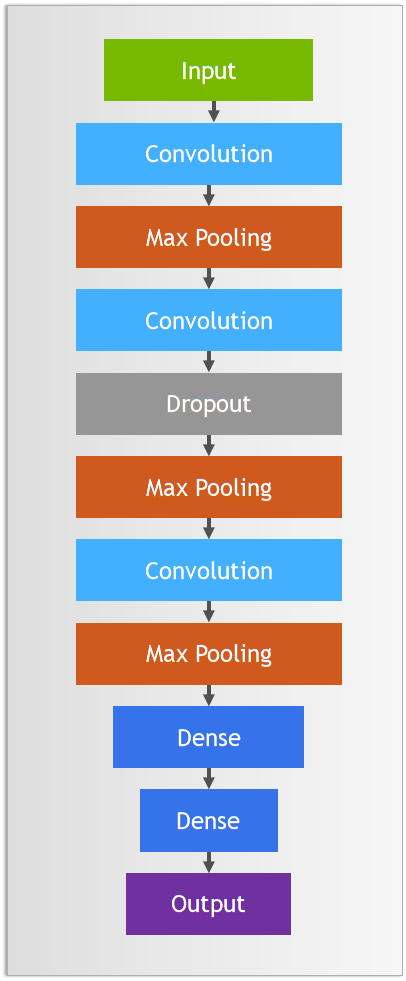<img src=«images/cnn.png» width=180 />

Hemos cubierto muchos de los diferentes tipos de capas en la conferencia, y vamos a ir sobre todos ellos aquí con enlaces a su documentación. En caso de duda, lee la documentación oficial (o pregunta en [Stack Overflow](https://stackoverflow.com/)).

In [41]:
n_classes = 10
kernel_size = 3
flattened_img_size = 75 * 3 * 3

model = nn.Sequential(
    # First convolution
    nn.Conv2d(IMG_CHS, 25, kernel_size, stride=1, padding=1),  # 25 x 28 x 28
    nn.BatchNorm2d(25),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14
    # Second convolution
    nn.Conv2d(25, 50, kernel_size, stride=1, padding=1),  # 50 x 14 x 14
    nn.BatchNorm2d(50),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7
    # Third convolution
    nn.Conv2d(50, 75, kernel_size, stride=1, padding=1),  # 75 x 7 x 7
    nn.BatchNorm2d(75),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3
    # Flatten to Dense
    nn.Flatten(),
    nn.Linear(flattened_img_size, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, n_classes)
)

### 3.3.1 [Conv2D](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)

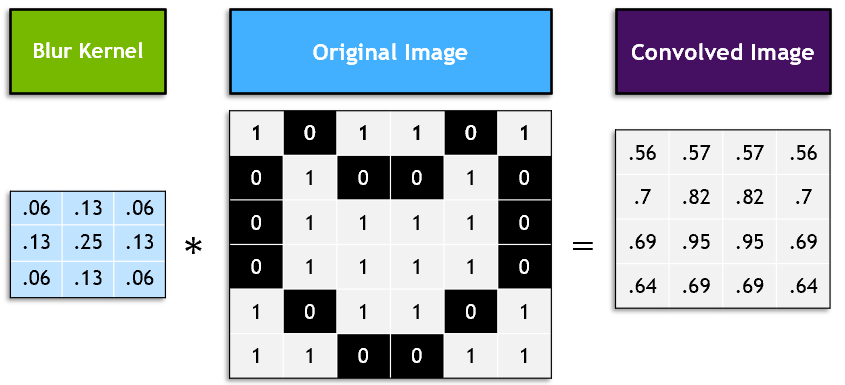

Estas son nuestras capas convolucionales 2D. Los núcleos pequeños repasarán la imagen de entrada y detectarán las características importantes para la clasificación. Las primeras convoluciones del modelo detectarán características simples, como líneas. Las convoluciones posteriores detectarán características más complejas. Veamos nuestra primera capa Conv2D:
```Python
nn.Conv2d(IMG_CHS, 25, kernel_size, stride=1, padding=1)
```
25 se refiere al número de filtros que se aprenderán. Aunque `kernel_size = 3`, PyTorch asumirá que queremos 3 x 3 filtros. Stride se refiere al tamaño del paso que dará el filtro al pasar sobre la imagen. Padding se refiere a si la imagen de salida que se crea a partir del filtro coincidirá con el tamaño de la imagen de entrada.

### 3.3.2 [BatchNormalization](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)

Al igual que la normalización de nuestras entradas, la normalización por lotes escala los valores en las capas ocultas para mejorar el entrenamiento. [Más información al respecto aquí](https://blog.paperspace.com/busting-the-myths-about-batch-normalization/).

Existe un debate sobre la mejor forma de colocar la capa de normalización por lotes. [Este post de Stack Overflow](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) recopila muchas perspectivas.

### 3.3.3 [MaxPool2D](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

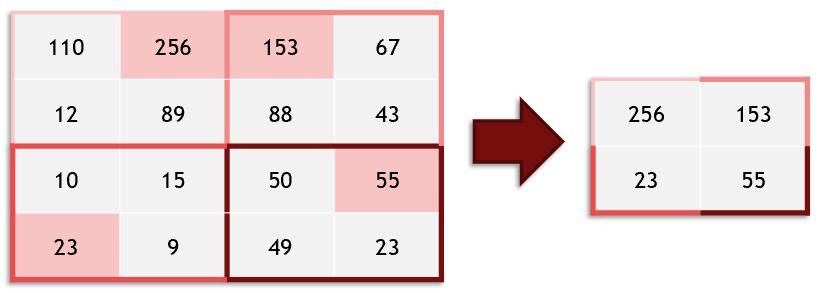

Max pooling toma una imagen y la reduce a una resolución menor. De este modo, el modelo es más resistente a la traslación (objetos que se mueven de un lado a otro) y, además, es más rápido.

### 3.3.4 [Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

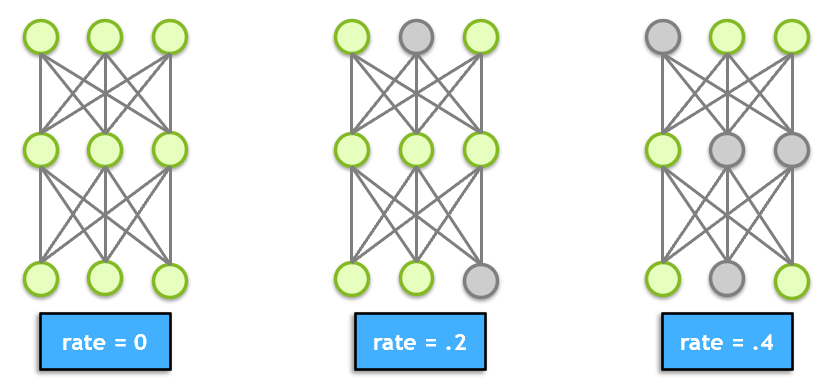

Dropout es una técnica para evitar el sobreajuste. Dropout selecciona aleatoriamente un subconjunto de neuronas y las desactiva, de modo que no participan en la propagación hacia delante o hacia atrás en ese paso concreto. Esto ayuda a garantizar que la red sea robusta y redundante, y no dependa de una sola área para obtener respuestas.

### 3.3.5 [Flatten](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

Aplanar toma la salida de una capa, que es multidimensional, y la aplana en una matriz unidimensional. La salida se denomina vector de características y se conectará a la capa de clasificación final.

### 3.3.6 [Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)

Ya hemos visto capas lineales densas en nuestros modelos anteriores. Nuestra primera capa densa (512 unidades) toma el vector de características como entrada y aprende qué características contribuirán a una clasificación concreta. La segunda capa densa (24 unidades) es la capa de clasificación final que genera nuestra predicción.

## 3.4 Resumiendo el modelo

Esto puede parecer mucha información, pero no te preocupes. No es fundamental que lo entiendas todo ahora mismo para poder entrenar eficazmente los modelos convolucionales. Lo más importante es que sabemos que pueden ayudar a extraer información útil de las imágenes y que pueden utilizarse en tareas de clasificación.

In [42]:
model = torch.compile(model.to(device))
model

OptimizedModule(
  (_orig_mod): Sequential(
    (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=675, out_features=512, bias=True)
    (15): Dropout

Como el problema que intentamos resolver sigue siendo el mismo (clasificar imágenes ASL), seguiremos utilizando la misma `función_de_pérdida` y la misma métrica de `precisión`.

In [43]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())

In [44]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

### 3.5 Entrenamiento del modelo

A pesar de que la arquitectura del modelo es muy diferente, el entrenamiento es exactamente igual.

#### Ejercicio

Se trata de las mismas funciones `train` y `validate` que antes, pero se han mezclado. ¿Puedes nombrar correctamente cada función y reemplazar los `FIXME`s?

Una de ellas debería tener `model.train` y la otra `model.eval`.

In [45]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [46]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [47]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

epochs = 3

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 217.4616 Accuracy: 0.9643
Valid - Loss: 12.5775 Accuracy: 0.9861
Epoch: 1
Train - Loss: 91.6177 Accuracy: 0.9850
Valid - Loss: 11.0145 Accuracy: 0.9885
Epoch: 2
Train - Loss: 70.8804 Accuracy: 0.9879
Valid - Loss: 15.2656 Accuracy: 0.9840


In [48]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms as T

def test_MNIST(img_path, model):
    transform = T.Compose([
        T.Grayscale(),
        T.Resize((28, 28)),
        T.ToTensor(),
        T.Lambda(lambda x: 1 - x),     # Invertir colores
    ])
    image = Image.open(img_path)
    x = transform(image).unsqueeze(0).to(device)  # shape [1,1,28,28]

    model.eval()
    with torch.no_grad():
        output = model(x)
        prob = torch.softmax(output, dim=1).cpu().numpy().flatten()
        pred = prob.argmax()

    # Mostrar distribución
    sns.barplot(x=list(range(10)), y=prob)
    plt.title(f"Predicción: {pred}")
    plt.show()

    return pred, prob

In [49]:
import os

def evaluar_carpeta_local(nombre_carpeta, model):
    folder_path = os.path.join('/content', nombre_carpeta)

    if not os.path.exists(folder_path):
        print(f"❌ Carpeta no encontrada: {folder_path}")
        return

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, fname)
            print(f"🖼️ Imagen: {nombre_carpeta}/{fname}")
            pred, prob = test_MNIST(img_path, model)
            print(f"📢 Predicción: {pred}")
            print("-" * 40)


📂 Evaluando carpeta: Normales
🖼️ Imagen: Normales/0.png


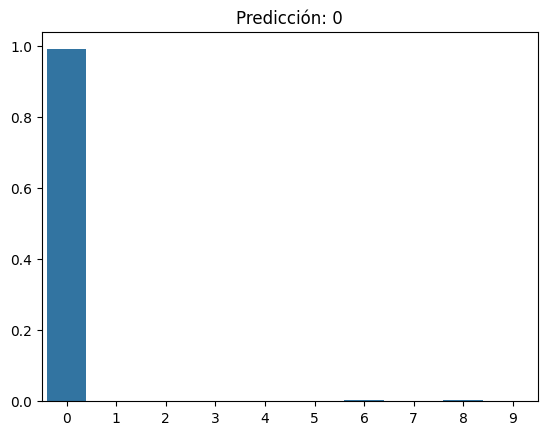

📢 Predicción: 0
----------------------------------------
🖼️ Imagen: Normales/1.png


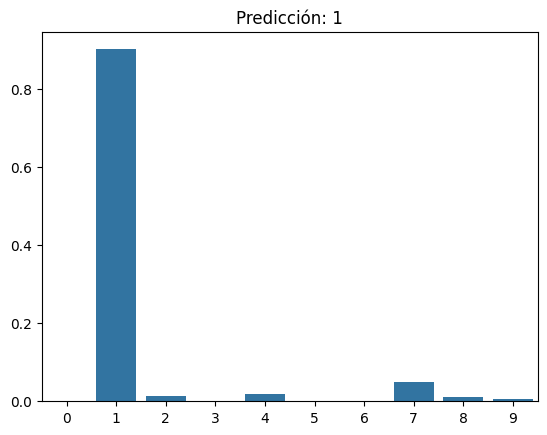

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Normales/2.png


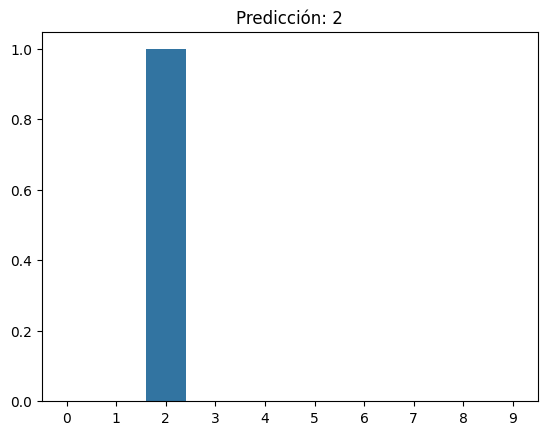

📢 Predicción: 2
----------------------------------------
🖼️ Imagen: Normales/3.png


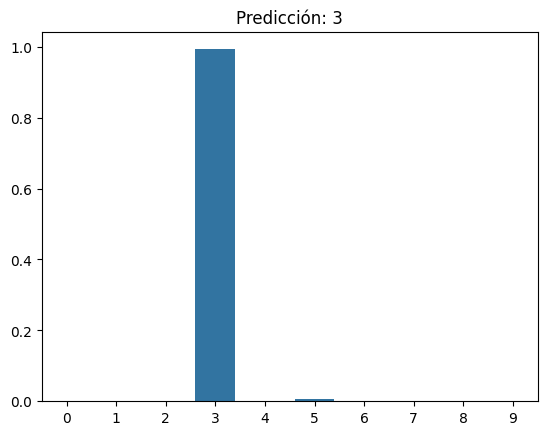

📢 Predicción: 3
----------------------------------------
🖼️ Imagen: Normales/4.png


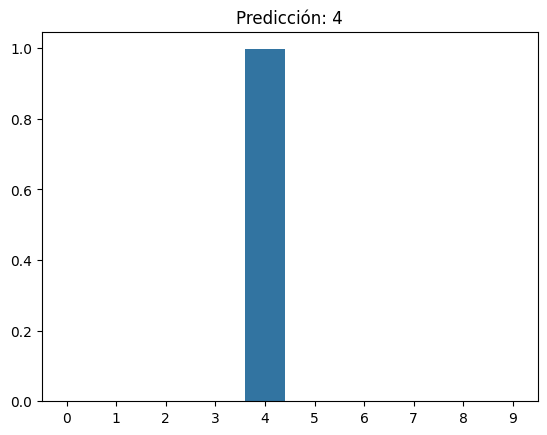

📢 Predicción: 4
----------------------------------------
🖼️ Imagen: Normales/5.png


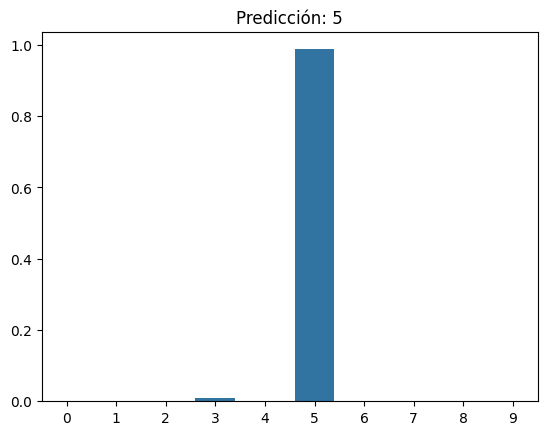

📢 Predicción: 5
----------------------------------------
🖼️ Imagen: Normales/6.png


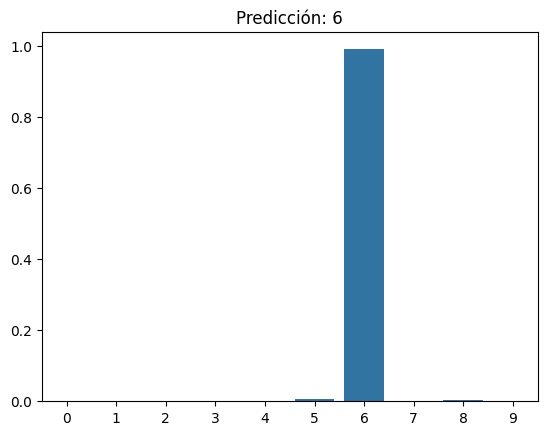

📢 Predicción: 6
----------------------------------------
🖼️ Imagen: Normales/7.png


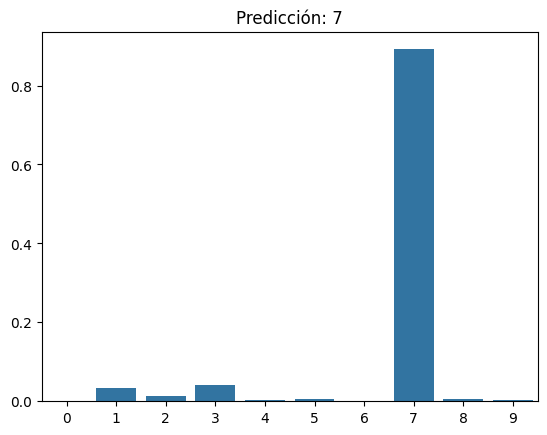

📢 Predicción: 7
----------------------------------------
🖼️ Imagen: Normales/8.png


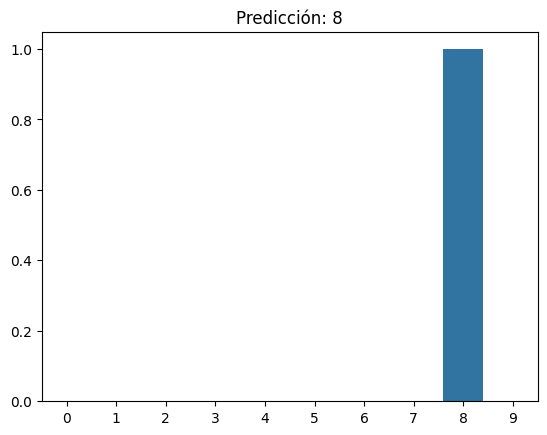

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Normales/9.png


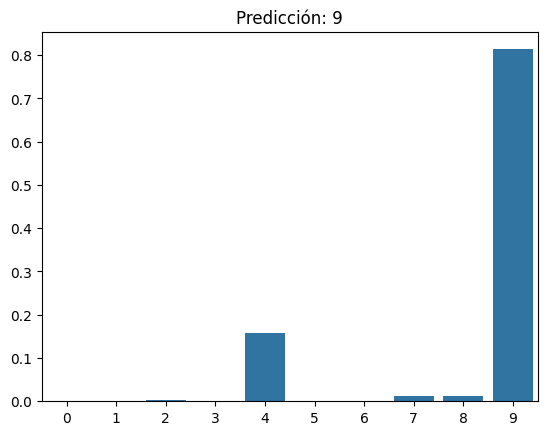

📢 Predicción: 9
----------------------------------------

📂 Evaluando carpeta: SinRelacion
🖼️ Imagen: SinRelacion/Asterisco.png


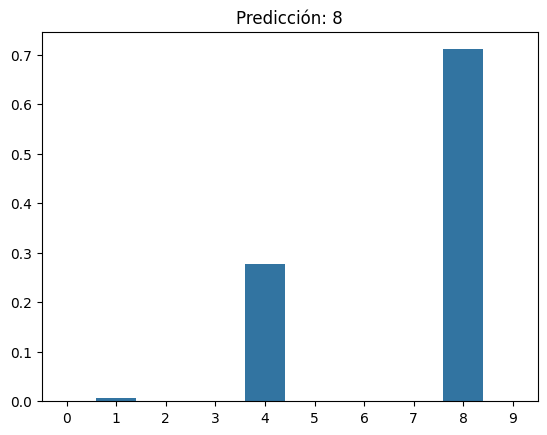

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: SinRelacion/Corazon.png


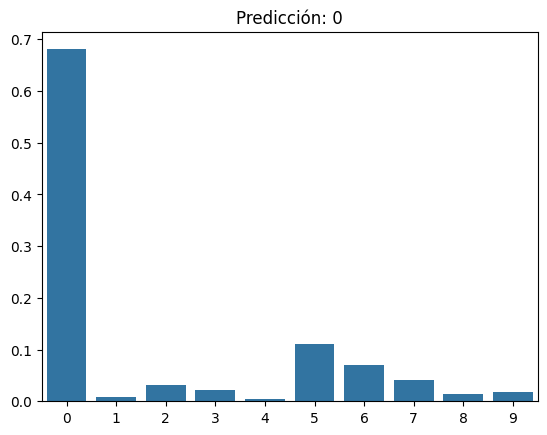

📢 Predicción: 0
----------------------------------------
🖼️ Imagen: SinRelacion/Dolar.png


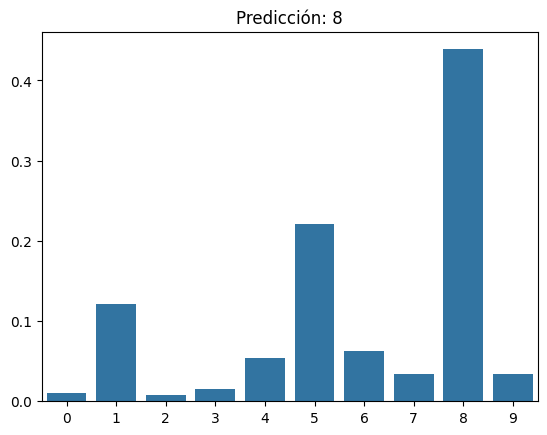

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: SinRelacion/E.png


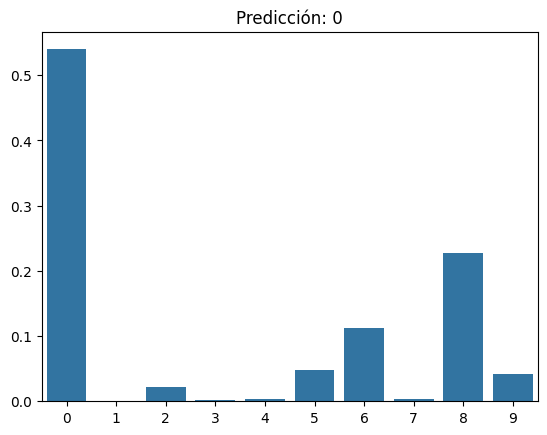

📢 Predicción: 0
----------------------------------------
🖼️ Imagen: SinRelacion/Estrella.png


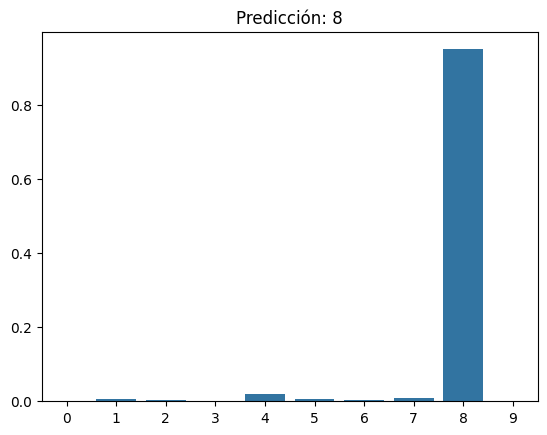

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: SinRelacion/Numeral.png


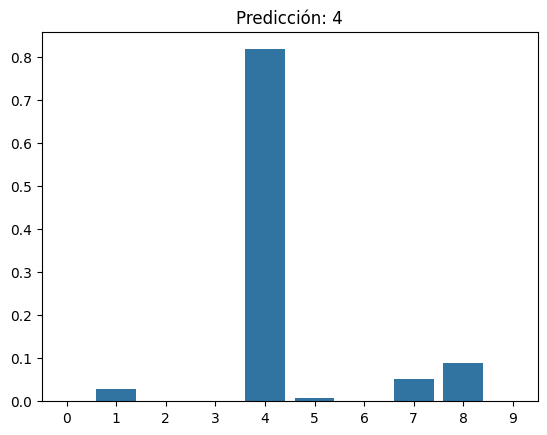

📢 Predicción: 4
----------------------------------------
🖼️ Imagen: SinRelacion/PI.png


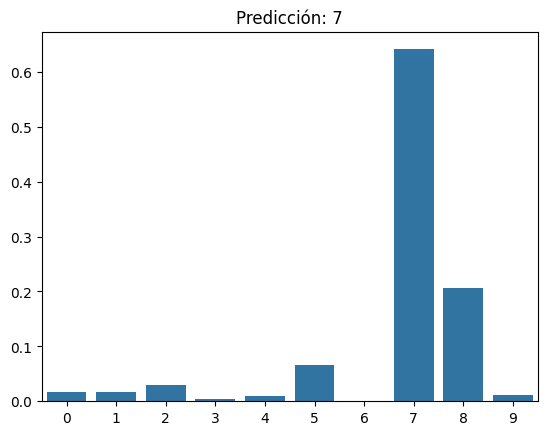

📢 Predicción: 7
----------------------------------------
🖼️ Imagen: SinRelacion/Porcentaje.png


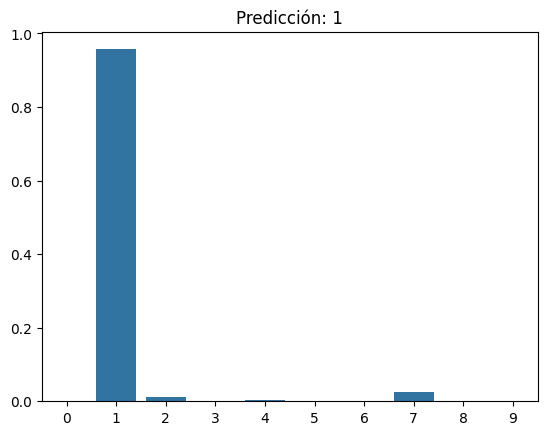

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: SinRelacion/Tilde.png


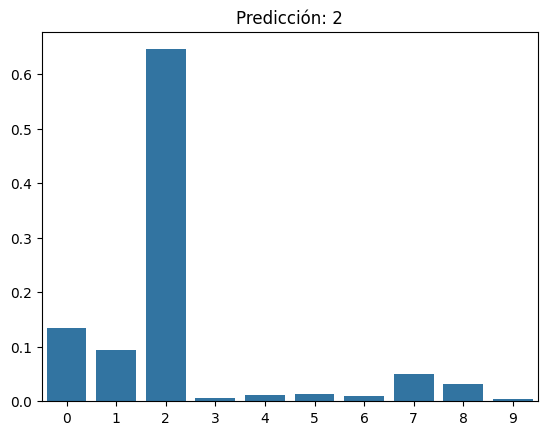

📢 Predicción: 2
----------------------------------------
🖼️ Imagen: SinRelacion/X.png


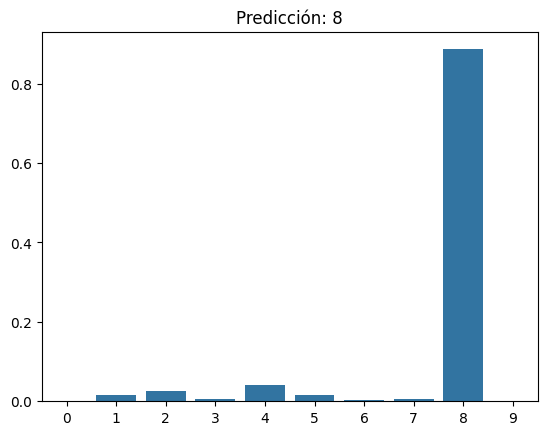

📢 Predicción: 8
----------------------------------------

📂 Evaluando carpeta: Rotados
🖼️ Imagen: Rotados/0.png


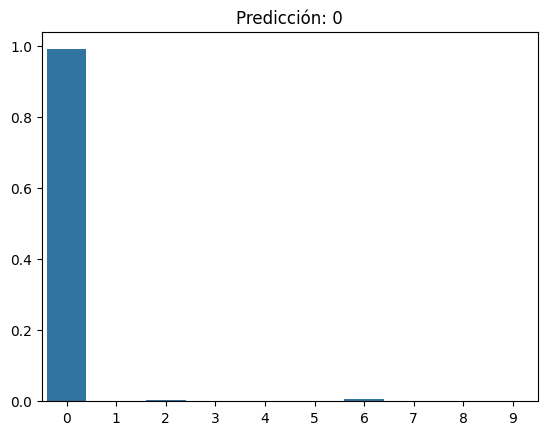

📢 Predicción: 0
----------------------------------------
🖼️ Imagen: Rotados/1.png


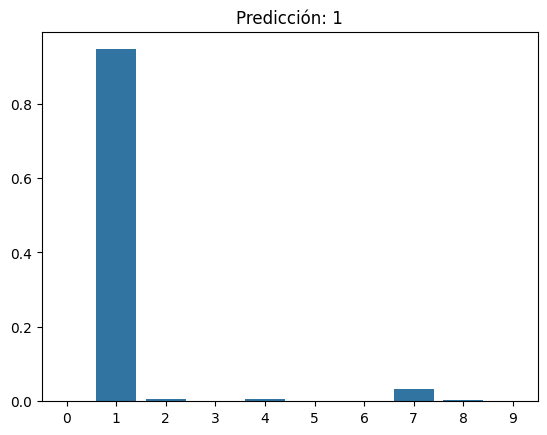

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Rotados/2.png


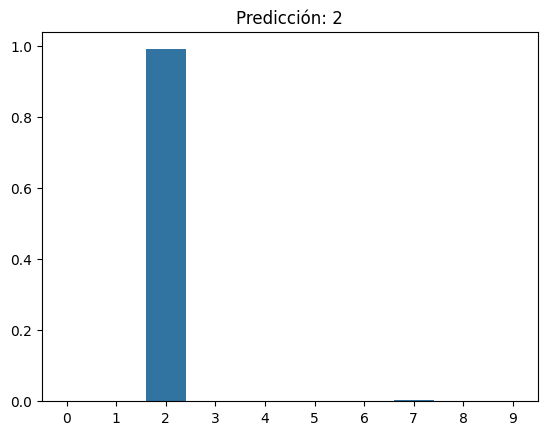

📢 Predicción: 2
----------------------------------------
🖼️ Imagen: Rotados/3.png


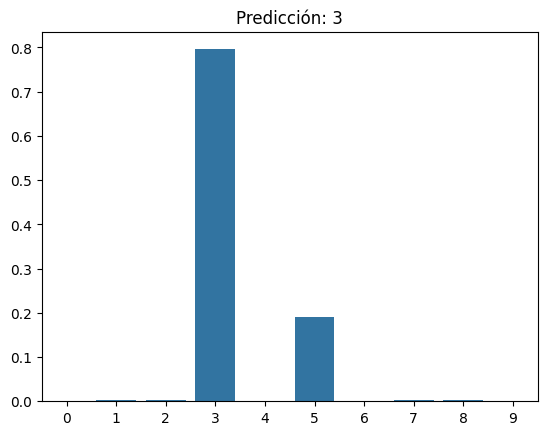

📢 Predicción: 3
----------------------------------------
🖼️ Imagen: Rotados/4.png


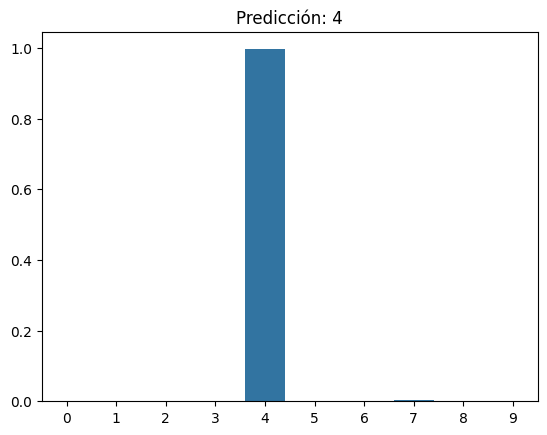

📢 Predicción: 4
----------------------------------------
🖼️ Imagen: Rotados/5.png


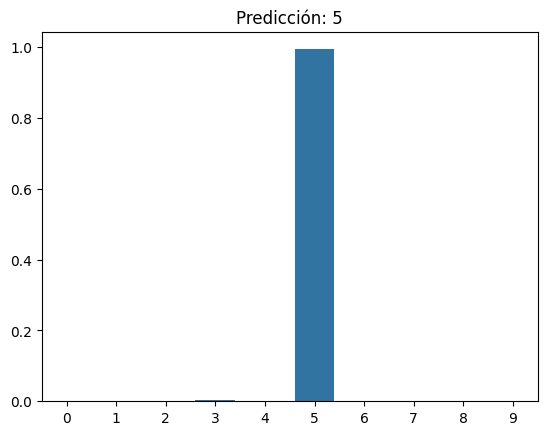

📢 Predicción: 5
----------------------------------------
🖼️ Imagen: Rotados/6.png


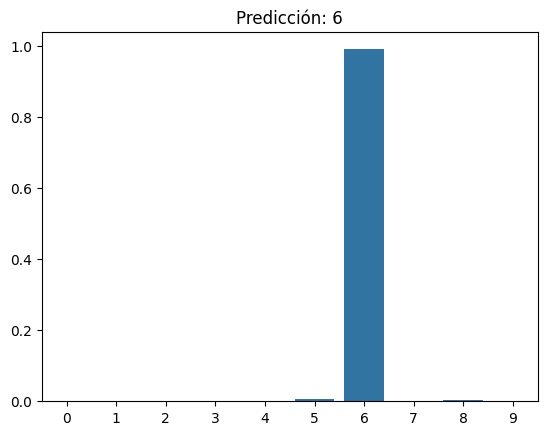

📢 Predicción: 6
----------------------------------------
🖼️ Imagen: Rotados/7.png


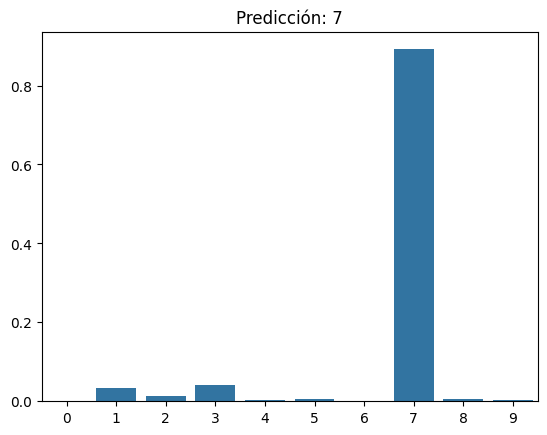

📢 Predicción: 7
----------------------------------------
🖼️ Imagen: Rotados/8.png


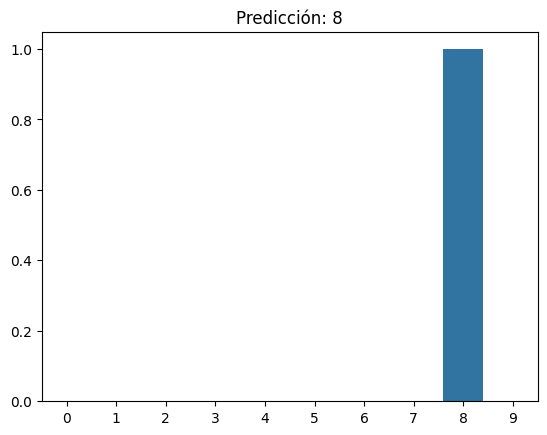

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Rotados/9.png


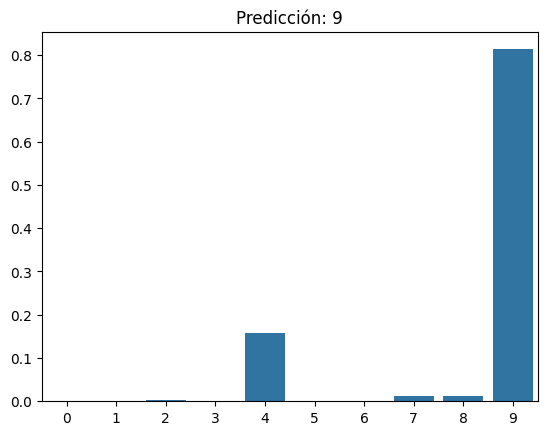

📢 Predicción: 9
----------------------------------------

📂 Evaluando carpeta: Ruido
🖼️ Imagen: Ruido/0.png


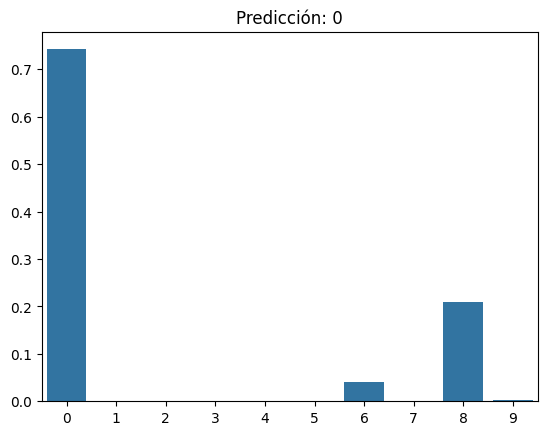

📢 Predicción: 0
----------------------------------------
🖼️ Imagen: Ruido/1.png


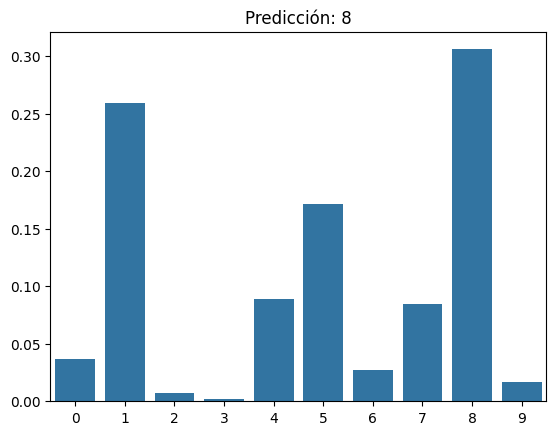

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Ruido/2.png


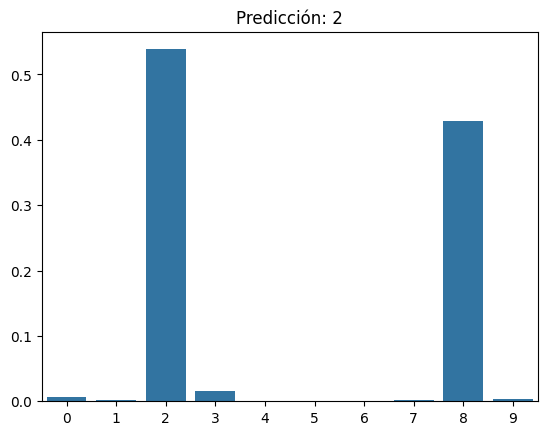

📢 Predicción: 2
----------------------------------------
🖼️ Imagen: Ruido/3.png


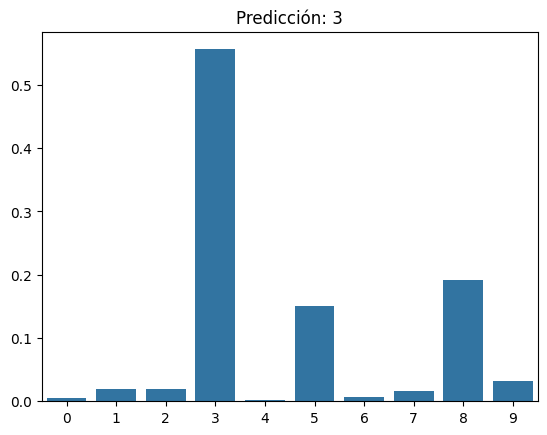

📢 Predicción: 3
----------------------------------------
🖼️ Imagen: Ruido/4.png


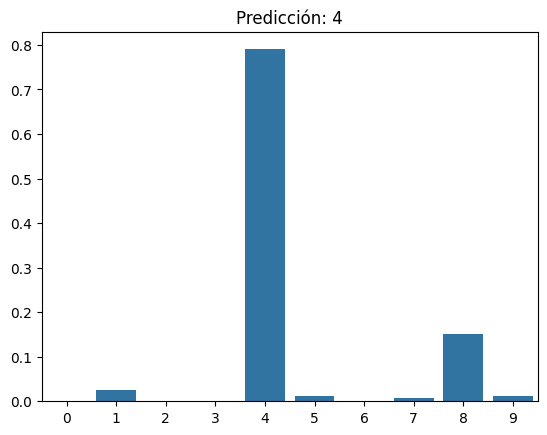

📢 Predicción: 4
----------------------------------------
🖼️ Imagen: Ruido/5.png


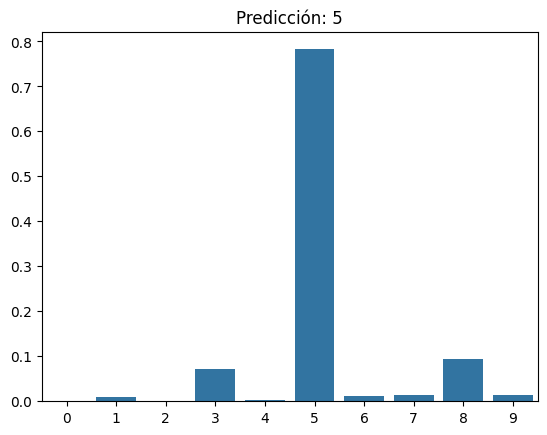

📢 Predicción: 5
----------------------------------------
🖼️ Imagen: Ruido/6.png


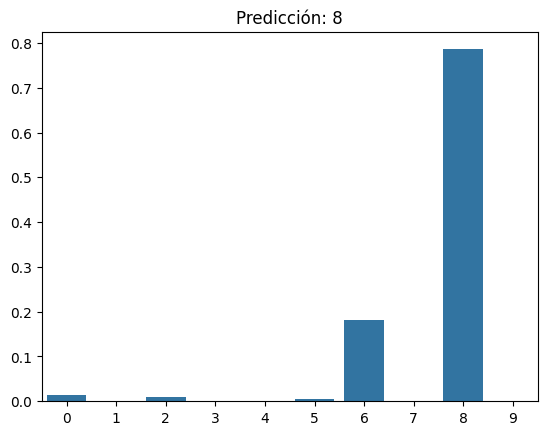

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Ruido/7.png


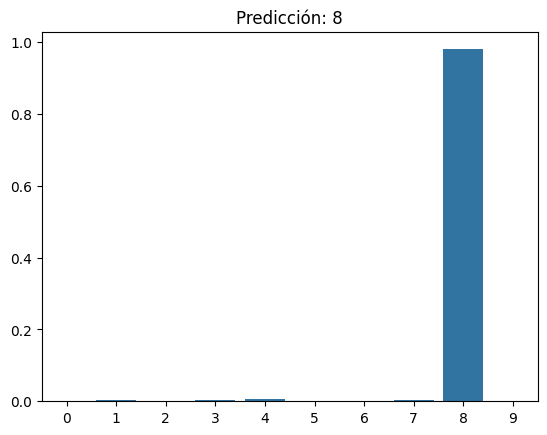

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Ruido/8.png


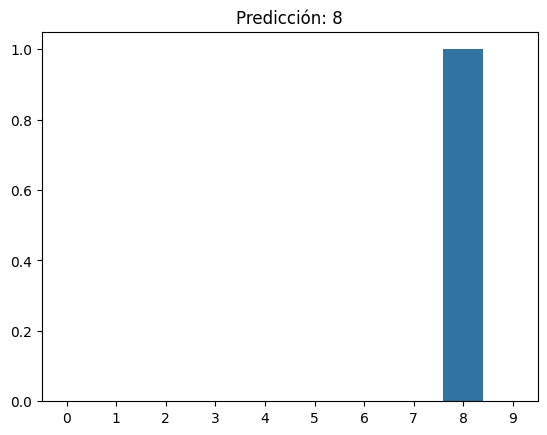

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Ruido/9.png


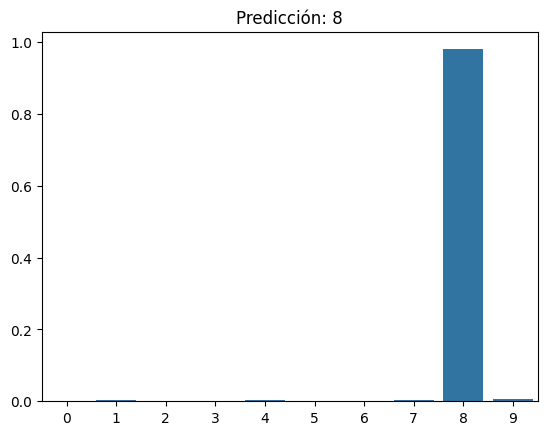

📢 Predicción: 8
----------------------------------------

📂 Evaluando carpeta: Especiales
🖼️ Imagen: Especiales/0.png


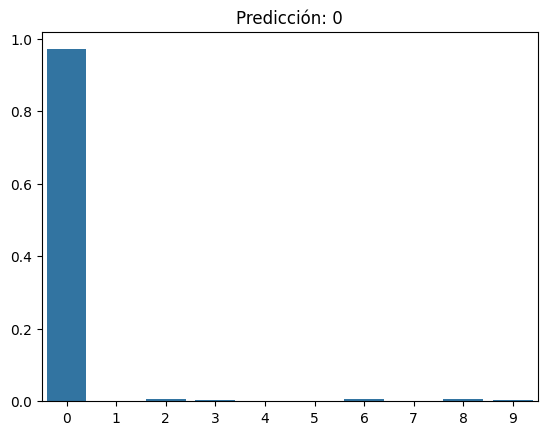

📢 Predicción: 0
----------------------------------------
🖼️ Imagen: Especiales/1.png


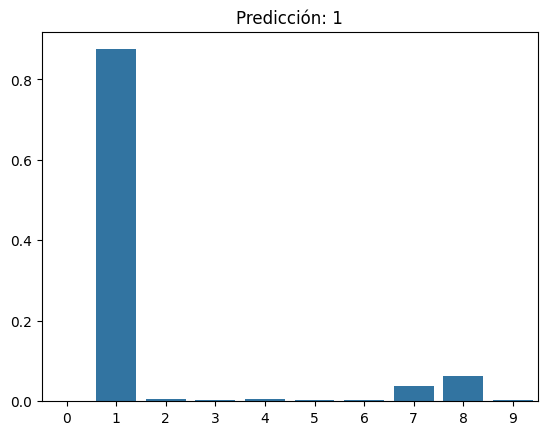

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Especiales/2.png


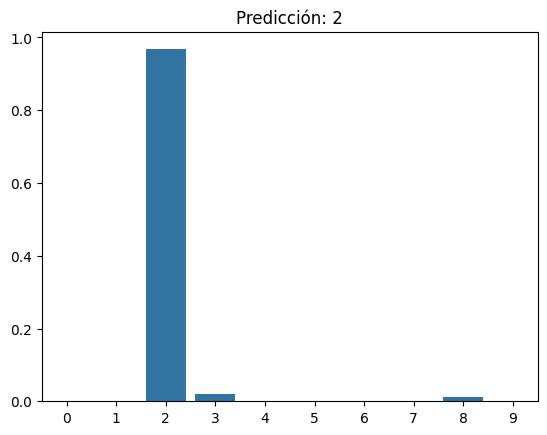

📢 Predicción: 2
----------------------------------------
🖼️ Imagen: Especiales/3.png


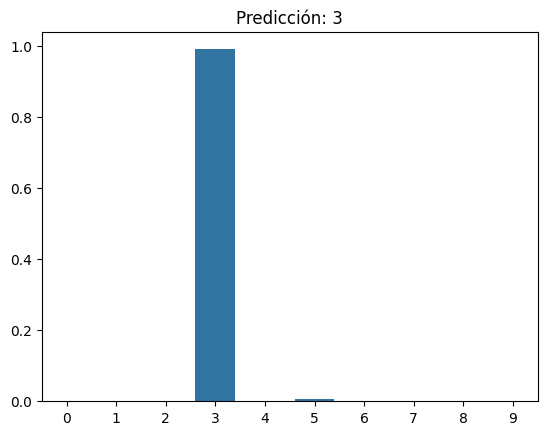

📢 Predicción: 3
----------------------------------------
🖼️ Imagen: Especiales/4.png


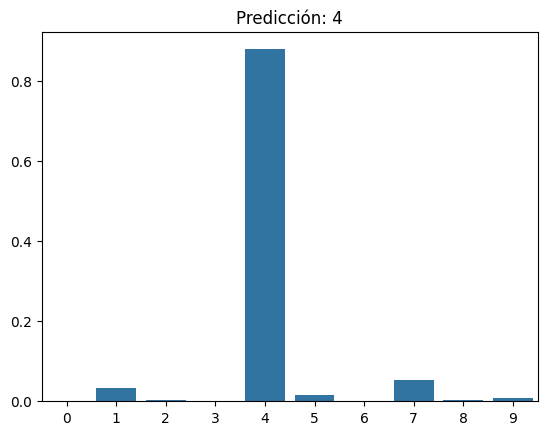

📢 Predicción: 4
----------------------------------------
🖼️ Imagen: Especiales/5.png


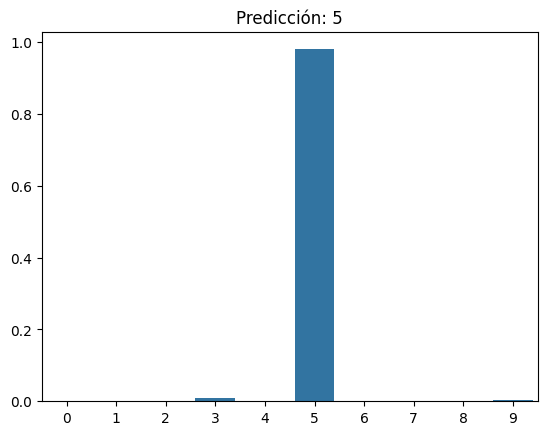

📢 Predicción: 5
----------------------------------------
🖼️ Imagen: Especiales/6.png


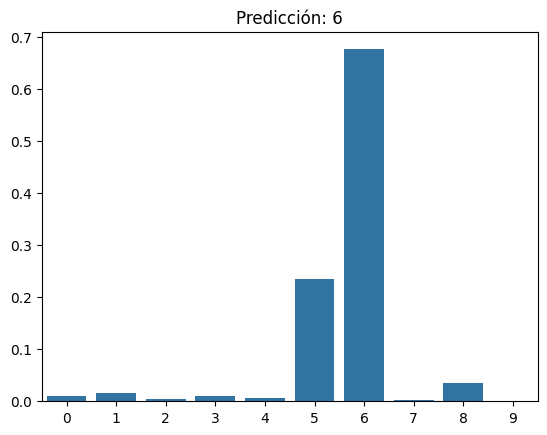

📢 Predicción: 6
----------------------------------------
🖼️ Imagen: Especiales/7.png


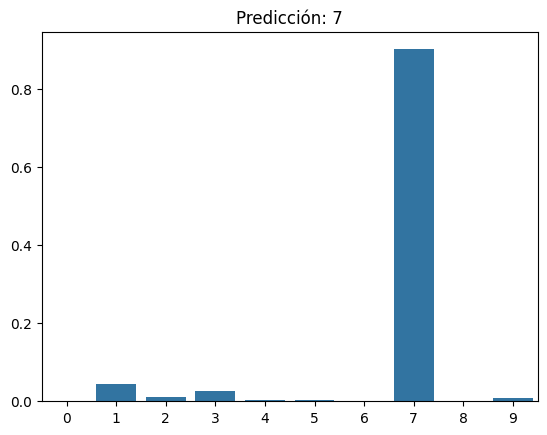

📢 Predicción: 7
----------------------------------------
🖼️ Imagen: Especiales/8.png


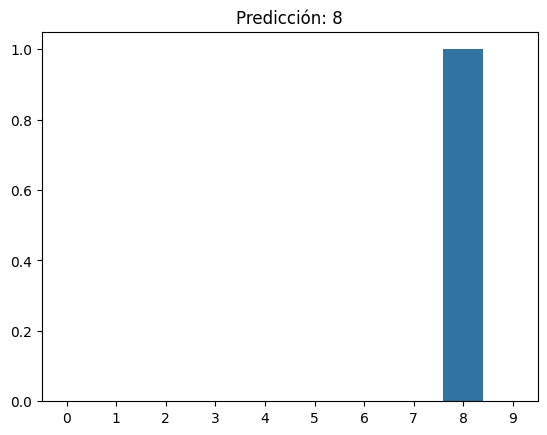

📢 Predicción: 8
----------------------------------------
🖼️ Imagen: Especiales/9.png


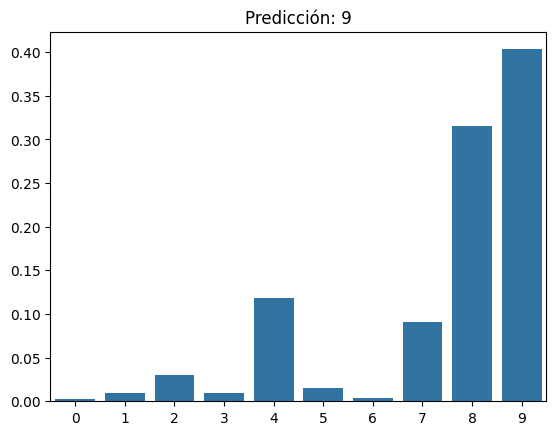

📢 Predicción: 9
----------------------------------------

📂 Evaluando carpeta: Cortados
🖼️ Imagen: Cortados/0.png


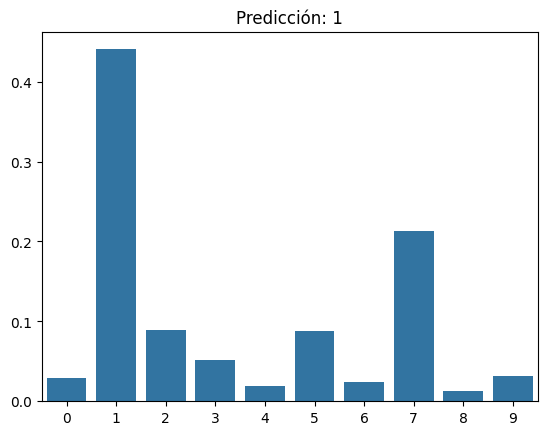

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/1.png


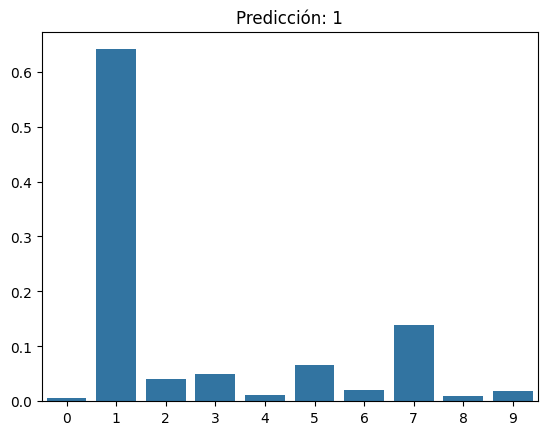

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/2.png


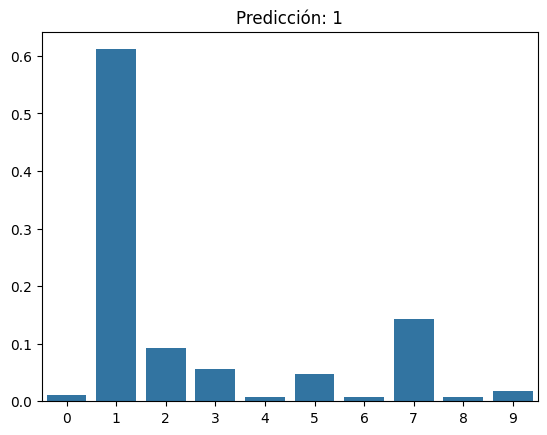

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/3.png


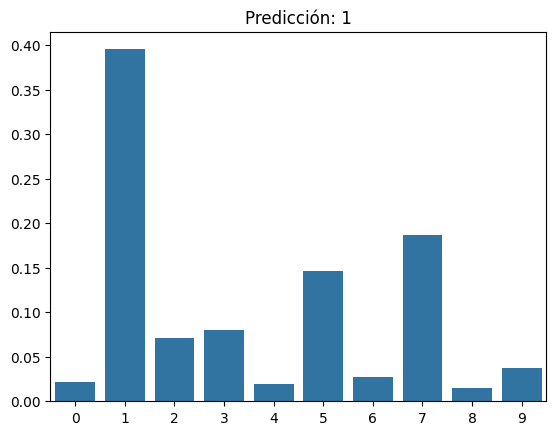

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/4.png


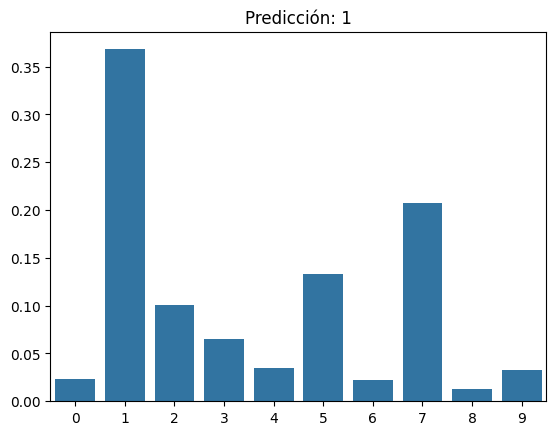

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/5.png


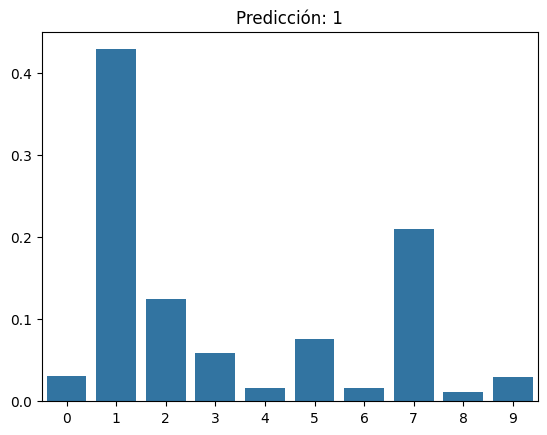

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/6.png


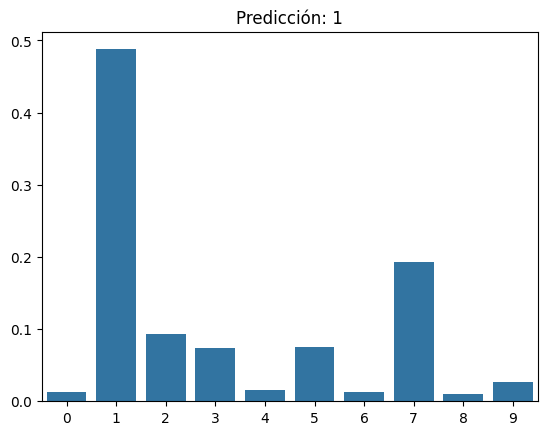

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/7.png


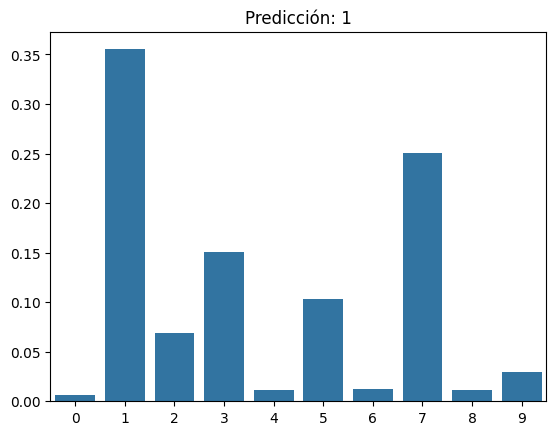

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/8.png


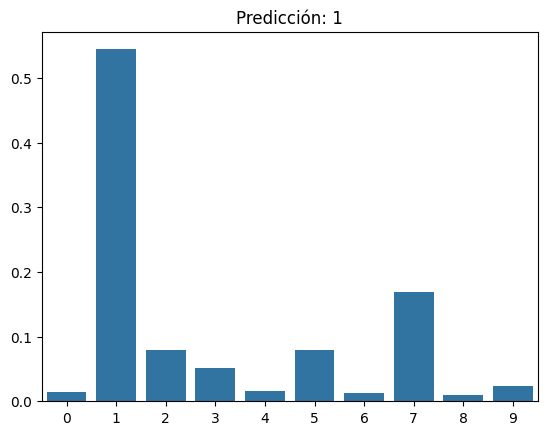

📢 Predicción: 1
----------------------------------------
🖼️ Imagen: Cortados/9.png


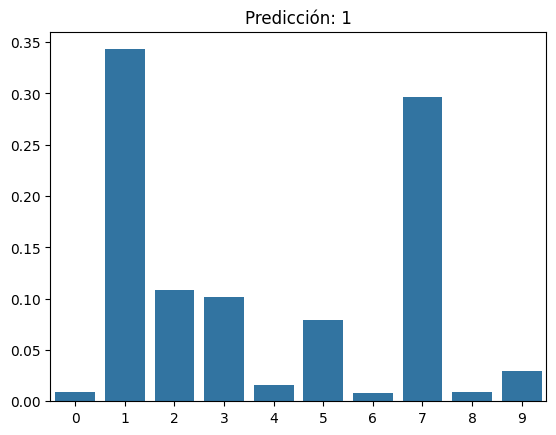

📢 Predicción: 1
----------------------------------------


In [50]:
carpetas = ['Normales', 'SinRelacion', 'Rotados', 'Ruido', 'Especiales', 'Cortados']

for carpeta in carpetas:
    print(f"\n📂 Evaluando carpeta: {carpeta}")
    evaluar_carpeta_local(carpeta, model)

In [ ]:
torch.save(model, 'model.pth')

### 3.5.1 Discusión de los resultados

En cuanto a los resultados de los numeros normales, el experimento analiza los numeros generalmente sin problemas. Sin embargo, como el modelo no es infalible, puede fallar en algunos casos. Generalmente en el 9

En el caso de los numeros sin relacion alguna, generalmente toman o activan la neurona del numero que mas se le acerque, por ejemplo el signo de porcentaje tiende a activar la neurona 1.

En el caso de los numeros rotados, igualmente tienden a funcionar correctamente. Sin embargo, en algunas ocasiones el modelo tiende a confundir el numero 3 con un 5 pues en algunas ocasiones lo considera un 5 volteado.

En cuanto a los numeros de naturaleza 'Especial' de manera similar estos tienden a ser analizados sin problemas pues las variaciones entre los numeros normales y estos no es muy significativa.

En cuanto a la presencia de ruido, esta es mas compleja pues la posicion y la cantidad de ruido tiende a alterar la percepcion del modelo con respecto a la figura y, en consecuencia, puede presentar fallos. Si bien el modelo, no tiene una eficacia del 100% en esta situación, puede ser considerada aceptable.

Lamentablemente, los cortes evidenciados en las imagenes del modelo hacen que el modelo se confunda y considere a los pequeños cortes que hay en la imagen como otro digito aparte, por esa razon considera a los numeros presentes como multiples instancias del numero 1 en la imagen al momento de analizar.

## 3.6 Resumen